In [717]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
import linearmodels.panel as lmp
import pytwoway as tw
import bipartitepandas as bpd
import seaborn as sns
from linearmodels.iv import IV2SLS

**Variable dictionary**

- folio_n20:	identificacion individuo
- year:	anio 20xx
- time:	ronda de la encuesta (1-7)
- age:	edad
- hombre:	1 si hombre, 0 mujer
- edu:	educacion medida en anios completados
- region:	region (1-16)
- status:	1 casado 2 convive 3 divorciado 4 viudo 5 soltero
- kids:	1 if has kids, 0 ow
- children:	# of children under 18 years old, 18 included
- situation:	1 otro, 2 cesante, 3 trabajando, 4 inactivo
- lmp:	1 part-time worker, 2 full-time worker, 0 not working
- exp:	years of labor experience
- size:	tamanio de la firma
- occupation:	codigo ocupacion
- wage:	salario mensual en pesos del anio encuesta
- hours:	horas semanales trabajadas
- informal:	1 if no work contract, 0 ow
- selfemp:	1 if self employed, 0 ow
- publicemp:	1 if worker in public sector, 0 ow
- sistema:	1 if in AFP system, 0 ow
- cotizando:	1 if contributor, 0 ow
- assets:	accumulated wealth in pension system, pesos of each year
- exp_sist:	years of experience in pension system
- expectancy:	expectativa de vida autorreportada
- illness:	1 si tiene al menos una enferdad, 0 si no
- cronica:	Si tiene enfermedad cronica 1, 0 eoc
- nocronica:	Si tiene enfermedad no cronica 1, 0 eoc
- mental:	Si tiene enfermedad mental 1, 0 eoc


Preguntas:

1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. 

2. Ejecute un modelo Pooled OLS para estimar la relacion entre los anios de educacion y la expectativa de vida. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

3. Ejecute un modelo efectos fijos para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

4. Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. 

5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

6. Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?

7. Usando el modelo CRE, prediga la distribucion del componente no observado. Que puede inferir respecto de la heterogeneidad fija en el tiempo y su impacto en la expectativa de vida?
8. Usando sus respuestas anteriores, que modelo prefiere? que se puede inferir en general respecto del efecto de las variables explicativas sobre la expectativa de vida?
9. Bonus track (optativo): Es posible que sus resultados anteriores tengan sesgo dado que quienes esperan vivir mas pueden estar incentivados a adquirir mas educacion. Proponga AL MENOS DOS instrumentos posibles para predecir el nivel de educacion de forma exogena, tal que se pueda corregir el sesgo y entender el efecto causal de las educacion en la expectativa de vida. Realice su estimacion considerando un modelo agrupado (ignorando el tiempo), y el modelo de panel.

# Formato del Notebook

En este notebook se responden las preguntas planteadas, marcando cada respuesta con **R:** para facilitar su identificación. Las respuestas se ubican al inicio del notebook, pero se hace referencia a las secciones específicas del desarrollo del código donde se implementa lo explicado, para que el lector pueda consultar los detalles según sea necesario.

## Partes del Código

A continuación se presenta la estructura del desarrollo del código:
### Preguntas y Respuestas
### 1) Carga de Datos y Análisis Descriptivo
- **1.1** Limpieza de datos y análisis descriptivo.  
- **1.2** Eliminación de los periodos 1 y 6.  
- **1.3** Creación de una variable binaria para representación laboral.  
- **1.4** Variable indicadora para variables relacionadas con lo laboral.  
- **1.5** Creación de variables dummies, tratamiento de outliers y manipulación de los datos para los modelos.  
- **1.6** Verificación del DataFrame utilizado para correr los modelos.  
- **1.7** Uso de `set_index` para ajustar la estructura del DataFrame.  
### 2) Modelos Re,Pooled y Fe
- **2.1** Modelo Pooled
- **2.2** Modelo Fe
- **2.3** Modelo Re
### 3) Comparacion de modelos
- **3.1** Comparacion de modelos
- **3.2** Test de Hausman
### 4) Modelo Cre y analisis de heterogeneidad
- **4.1** Modelo CRE
- **4.2** Grafico para ver heterogeneidad
- **4.3** Comparacion de RE V/S FE V/S CRE
- **4.4** Estadistica complementaria





# Pregunta 1  
**R:** Al revisarel data frame, se observa que en los periodos de tiempo 1 y 6 existen muchos valores nulos en variables que considero importantes para el análisis, especialmente aquellas relacionadas con la salud, como la presencia de enfermedades crónicas, entre otras. Esta situación no se puede resolver imputando ceros, ya que esto introduciría ruido en el modelo. Por ello, considero pertinente eliminar los periodos 1 y 6 del análisis,lo cual se muestra en la parte `1.2` .
Además, se identificaron valores que no son nulos técnicamente, pero que corresponden a codificaciones de valores faltantes utilizadas por algunos softwares (por ejemplo, el valor 990 en la variable "expectancy"). Para limpiar estos valores, se optó por conservar solo aquellos registros donde "expectancy" es menor o igual a 130.
Luego de esta limpieza, variables clave para el análisis como `educ` o `wage` quedaron mayoritariamente sin valores nulos, aunque con algunos *outliers*. Dado que estos casos son pocos y ya se ha reducido considerablemente el tamaño del dataset (pasando de 98.000 a 50.000 registros), se decidió conservarlos tal como están.
Con estas transformaciones, se obtuvo una base de datos limpia y adecuada para el desarrollo del resto del análisis,estos analisis se hacen en base a lo realizado en `1.5`,`1.6`.


# Pregunta 2  
**R:** Primero mencionaré el criterio utilizado para seleccionar las variables predictoras y la razón por la cual se descartaron algunas otras. Posteriormente, se presentará el resultado obtenido en el modelo *pooled*.

En primer lugar, se descartó la variable `edad`, ya que su representación en el DataFrame era inconsistente: en algunos registros se indicaba la fecha de nacimiento, en otros estaba modificada o errónea. Esta falta de homogeneidad hacía poco eficiente su uso y representaba una pérdida de tiempo incorporarla, considerando que existen muchas otras variables útiles para el análisis.

La selección de variables se basó principalmente en razonamiento lógico, ya que no se utilizaron métodos estadísticos como el *odds ratio* o matrices de correlación para determinar la significancia de las variables. Al analizar el DataFrame, se pueden identificar tres grandes bloques temáticos que agrupan las variables:  

1. **Vida laboral**  
2. **Atributos personales (educación y salud)**  
3. **Pensiones**

Estas áreas están fuertemente relacionadas con el nivel socioeconómico, lo que a su vez influye directamente en la expectativa de vida. Por esta razón, se seleccionaron variables que representaran cada uno de estos bloques:

### 1. Vida laboral
Se incluyeron tres variables:

- `Suitation`: refleja la situación laboral de la persona. Esta se transformó en una variable binaria llamada `trabaja_binaria`, que indica simplemente si la persona trabaja o no. Este proceso está detallado en la sección **1.3**.
- `exp`: representa los años de experiencia laboral. Dado que esta variable puede estar ausente en personas que no trabajan, se creó una variable indicadora llamada `info_lab_fal` para este tipo de suitaciones, lo cual se detalla en la sección **1.4**.
- `occupation`: permite evaluar cómo el tipo de ocupación afecta la calidad de vida.

Otras variables laborales se descartaron por considerarse redundantes o demasiado específicas, como `lmp`, que podría generar multicolinealidad con las variables ya seleccionadas.

### 2. Atributos personales
Se incluyeron las siguientes variables:

- `educ`: años de educación.
- `wage`: ingresos. Como esta relacionada con `trabaja_binaria` se decido incluirla en el analisis en la creacion `info_lab_fal`.
- Todas las variables relacionadas con la salud, ya que representan de forma cuantificable los atributos personales relevantes para la expectativa de vida.

Se excluyeron variables que varían poco en el tiempo, como región o estado civil, ya que las variables seleccionadas cubren suficientemente los aspectos personales.

### 3. Pensiones
Se seleccionaron dos variables:

- `assets`: refleja el monto acumulado por la persona, lo cual puede influir en su calidad y expectativa de vida.
- `sistema`: permite comparar si pertenecer a un sistema como la AFP afecta la expectativa de vida.

En resumen, se buscaron variables que abordaran de forma equilibrada las áreas más influyentes sobre la expectativa de vida, evitando redundancias y priorizando aquellas con mayor capacidad explicativa.

# Interpretación de los Coeficientes del Modelo Pooled y resultados(parte 2.1)
Todos los resultados se encuentran en la parte dos pero se especificara en el titulo las partes que se utilizan para el analisis
hint:para ocupacion nos basaremos en la categorizacion de la ocupacion del ine(el 10 no se va a interpretar ya que no aparece,nuestro grupo base es 1 por lo cual serian   Directores, gerentes y administradores)
## Coeficientes estadísticamente significativos (p < 0.05)

# Interpretación de Coeficientes Significativos (p < 0.05)

| Variable            | Coeficiente | p-value  | Interpretación cuantitativa                                                                         |
|---------------------|-------------|----------|------------------------------------------------------------------------------------------------------|
| const               | 80.837      | 0.0000   | Expectativa base: 80.837 años cuando todas las otras variables son cero.                            |
| log_wage            | 0.0891      | 0.0038   | Aumentar el sueldo en 1 peso logarítmico en sueldo eleva la expectativa de vida en **+0.0891**.         |
| exp                 | 0.0635      | 0.0000   | Cada año adicional de experiencia laboral aumenta la expectativa de vida en **+0.0635**.        |
| log_assets          | 0.0230      | 0.0145   | Aumentar el patrimonio en 1 punto logarítmico incrementa la expectativa de vida en **+0.0230**.         |
| sistema             | -4.9002     | 0.0000   | Estar en AFP (vs. otro sistema) **reduce** la expectativa de vida en **−4.9002**.                   |
| assets_isnull       | 1.8275      | 0.0000   | No tener datos de patrimonio se asocia a **+1.8275** más de expectativa (posible sesgo).        |
| sistema_isnull      | -4.0421     | 0.0000   | No tener datos del sistema previsional se asocia a una **disminución de −4.0421**.              |
| trabaja_binaria     | -1.6941     | 0.0003   | Estar trabajando se asocia a una reducción de **−1.6941** en la expectativa de vida.            |
| occupation_2.0      | 1.3533      | 0.0000   | Profesionales viven **+1.3533** más que el grupo base.                                          |
| occupation_3.0      | 1.1373      | 0.0000   | Técnicos viven **+1.1373** más que el grupo base.                                               |
| occupation_5.0      | -1.1501     | 0.0000   | Vendedores/servicios viven **−1.1501** menos que el grupo base.                                |
| occupation_6.0      | -1.3082     | 0.0001   | Agricultores/ganaderos viven **−1.3082** menos.                                                |
| occupation_7.0      | -0.6556     | 0.0041   | Oficiales/operarios viven **−0.6556** menos que el grupo base.                                 |
| occupation_8.0      | -0.6174     | 0.0164   | Operadores de máquinas viven **−0.6174** menos.                                                |
| occupation_9.0      | -1.2695     | 0.0000   | Ocupaciones elementales viven **−1.2695** menos.                                               |
| cronica             | 1.8708      | 0.0000   | Tener enfermedad crónica se asocia a **+1.8708** más de expectativa (posible sesgo).            |
| mental              | -2.0155     | 0.0000   | Enfermedad mental reduce la expectativa de vida en **−2.0155**.                                |
| illness             | -1.7021     | 0.0000   | Enfermedades físicas reducen la expectativa de vida en **−1.7021**.                            |
| info_lab_fal        | 1.4258      | 0.0000   | Falta de info laboral se asocia a **+1.4258** de expectativa (posible sesgo).                  |


---

##  Coeficientes NO significativos (p ≥ 0.05)

| Variable            | Coeficiente | p-value  | Interpretación                                                                 |
|---------------------|-------------|----------|---------------------------------------------------------------------------------|
| edu                 | -0.0004     | 0.9686   | Educación no tiene un efecto claro.                                            |
| hours               | 0.0051      | 0.2294   | Horas trabajadas no tienen un impacto claro.                                   |
| edu_isnull          | -0.5425     | 0.2248   | No tener datos de educación no es significativo.                               |
| occupation_4.0      | 0.0417      | 0.8751   | No se diferencia del grupo base.                                               |
| occupation_10.0     | 2.1772      | 0.1922   | Alta variabilidad; no se concluye efecto claro.                                |
| nocronica           | -0.3194     | 0.1164   | No tener enfermedades crónicas no cambia significativamente la expectativa.    |
| illness_isnull      | 0.9970      | 0.3584   | Falta de info sobre enfermedades no es significativa.                          |

## R2
El R² fue muy bajo, lo cual era esperable ya que es un modelo muy restrictivo. Sin embargo, la mayoría de las variables resultaron significativas. No se realizará ningún cambio en las variables, ya que es necesario mantener las mismas en todos los modelos para efectos de comparación.



# Pregunta 3
**R:** 
### Interpretación de los Coeficientes del Modelo de efectos fijos y resultados(parte 2.2)
# Interpretación de Coeficientes Significativos (p < 0.05)

| Variable        | Coeficiente | p-value  | Interpretación cuantitativa                                                                 |
|-----------------|-------------|----------|----------------------------------------------------------------------------------------------|
| const           | 73.609      | 0.0000   | Expectativa base: 73.609 años cuando todas las otras variables son cero.                    |
| exp             | 0.3010      | 0.0000   | Cada año adicional de experiencia laboral aumenta la expectativa de vida en **+0.3010**.    |
| log_assets      | 0.0519      | 0.0022   | Aumentar el patrimonio en 1 punto logarítmico incrementa la expectativa de vida en **+0.0519**. |
| sistema         | -0.4978     | 0.0279   | Estar en AFP  **reduce** la expectativa de vida en **−0.4978**.                             |
| assets_isnull   | 2.1302      | 0.0000   | No tener datos de patrimonio se asocia a **+2.1302** más de expectativa (posible sesgo).    |
| occupation_2.0  | 1.1785      | 0.0057   | Profesionales viven **+1.1785** más que el grupo base.                                      |
| occupation_3.0  | 1.0439      | 0.0066   | Técnicos viven **+1.0439** más que el grupo base.                                           |
| occupation_6.0  | -1.0484     | 0.0379   | Agricultores/ganaderos viven **−1.0484** menos que el grupo base.                          |
| nocronica       | -0.9623     | 0.0010   | tener enfermedades no crónicas se asocia a **−0.9623**  menos de expectativa.           |
| mental          | -0.7566     | 0.0073   | Enfermedad mental reduce la expectativa de vida en **−0.7566**.                             |

## Coeficientes NO significativos (p ≥ 0.05)

| Variable         | Coeficiente | p-value  | Interpretación                                                                 |
|------------------|-------------|----------|---------------------------------------------------------------------------------|
| edu              | -0.0227     | 0.4517   | Educación no tiene un efecto claro sobre la expectativa de vida.               |
| log_wage         | -0.0113     | 0.8490   | Sueldo logarítmico no tiene un impacto claro.                                  |
| hours            | 0.0041      | 0.4929   | Horas trabajadas no tienen un efecto claro.                                    |
| edu_isnull       | 0.5784      | 0.4217   | No tener datos de educación no es significativo.                               |
| trabaja_binaria  | -0.0698     | 0.9327   | Estar trabajando no afecta significativamente la expectativa de vida.          |
| occupation_4.0   | 0.7129      | 0.0666   | Cerca de ser significativo; podría haber diferencia, pero no se concluye.      |
| occupation_5.0   | -0.0318     | 0.9280   | Vendedores/servicios no se diferencian del grupo base.                         |
| occupation_7.0   | 0.2142      | 0.5485   | Oficiales/operarios no presentan efecto claro.                                 |
| occupation_8.0   | -0.1823     | 0.6514   | Operadores de máquinas no presentan diferencia significativa.                  |
| occupation_9.0   | -0.1758     | 0.6108   | Ocupaciones elementales sin efecto significativo.                              |
| occupation_10.0  | 1.8806      | 0.4273   | Alta variabilidad; no se concluye efecto claro.                                |
| cronica          | -0.3626     | 0.1870   | Tener enfermedad crónica no es significativo (poco intuitivo; podría haber sesgo). |
| illness          | -0.4141     | 0.1155   | Enfermedad física no presenta un efecto claro.                                 |
| illness_isnull   | 1.7898      | 0.3999   | No tener info sobre enfermedades no es significativo.                          |
| info_lab_fal     | 0.5835      | 0.3633   | La falta de información laboral no se asocia significativamente a expectativa. |


 

# Pregunta 4
**R:** 
### Interpretación de los Coeficientes del Modelo de efectos aleatorios y resultados(parte 2.3)

## Coeficientes Significativos (p < 0.05)

| Variable         | Coef.    | p-valor | Interpretación Cuantitativa                                                                 |
|------------------|----------|---------|----------------------------------------------------------------------------------------------|
| const            | 77.724   | 0.0000  | Valor base esperado de esperanza de vida (77.72 años).                                      |
| log_wage         | 0.0798   | 0.0060  | Cada punto logarítmico adicional en salario aumenta la esperanza de vida en +0.0798    |
| exp              | 0.0876   | 0.0000  | Cada año de experiencia laboral suma +0.0876  de vida esperada.                         |
| sistema          | -1.5743  | 0.0000  | Estar en el sistema AFP reduce la esperanza de vida en −1.5743 .                        |
| assets_isnull    | 1.6865   | 0.0000  | No tener información sobre patrimonio se asocia a +1.6865 de expectativa vida.                     |
| trabaja_binaria  | -1.4682  | 0.0011  | Estar trabajando reduce la esperanza de vida en −1.4682 a.                               |
| occupation_2.0   | 1.3525   | 0.0000  | Profesionales tienen una expecativa +1.3525  más que el grupo base.                                     |
| occupation_3.0   | 1.0820   | 0.0000  | Técnicos tienen una expecativa +1.0820 años más que el grupo base.                                          |
| occupation_5.0   | -0.8324  | 0.0003  | Trabajadores de servicios/vendedores tienen una expectativa de vida de −0.8324 que el gruo base.                              |
| occupation_6.0   | -1.3501  | 0.0000  | Agricultores y afines tienen una expectativa de vida −1.3501 que el grupo base.                                             |
| occupation_7.0   | -0.4347  | 0.0491  | Oficiales/operarios tienen una expectativa de vida de −0.4347 comparado con el grupo base.     |
| occupation_8.0   | -0.5252  | 0.0380  | Operadores de maquinaria tienen una expectativa de vida de −0.5252 comparado con el grupo base.            |
| occupation_9.0   | -1.0108  | 0.0000  | Ocupaciones elementales tienen una expecativa de  −1.0108 comparado con el grupo base                                           |
| cronica          | 1.4217   | 0.0000  | Tener enfermedad crónica aumenta la esperanza de vida en +1.4217  (contraintuitivo).   |
| mental           | -1.6585  | 0.0000  | Tener enfermedad mental reduce la esperanza de vida en −1.6585.                        |
| illness          | -1.1830  | 0.0000  | Tener enfermedad física reduce la expectativa de vida en −1.1830 .                      |
| info_lab_fal     | 1.4954   | 0.0000  | Tener información laboral faltante se asocia a +1.4954  (posible sesgo de selección).   |

## Coeficientes NO Significativos (p ≥ 0.05)

| Variable         | Coef.    | p-valor | Interpretación                                                                            |
|------------------|----------|---------|-------------------------------------------------------------------------------------------|
| edu              | -0.0183  | 0.1195  | La educación no muestra un efecto claro.                                                  |
| hours            | 0.0013   | 0.7581  | Las horas trabajadas no afectan significativamente la esperanza de vida.                 |
| log_assets       | -0.0140  | 0.1410  | El patrimonio no muestra un impacto claro en la esperanza de vida.                       |
| edu_isnull       | -0.7549  | 0.1097  | No tener datos de educación no tiene efecto claro.                                       |
| occupation_4.0   | 0.2449   | 0.3312  | Empleados administrativos no se diferencian significativamente del grupo base.           |
| occupation_10.0  | 2.2680   | 0.0950  | Fuerzas armadas: efecto no concluyente, pero con posible tendencia positiva.             |
| nocronica        | -0.2391  | 0.2505  | No tener enfermedad crónica no se asocia significativamente a menor expectativa de vida. |
| illness_isnull   | 0.8450   | 0.5007  | No tener datos sobre enfermedades no es significativo.                                   |





# Pregunta 5
**R:** 
# Comparación de Modelos: Efectos Fijos vs. Efectos Aleatorios vs. Pooled OLS

## 1. Diferencias entre los modelos (parte 3.1)

### a. Supuestos y estructura

| Modelo         | Supuesto clave                                                                 | Controla por...                            |
|----------------|--------------------------------------------------------------------------------|--------------------------------------------|
| Pooled OLS     | No considera heterogeneidad individual                                         | Nada                                        |
| FE             | Los efectos individuales están correlacionados con los regresores              | Heterogeneidad no observada (invariante)   |
| RE             | Los efectos individuales no están correlacionados con los regresores           | Eficiencia si el supuesto se cumple        |

### b. ¿Por qué cambian los coeficientes?

- El modelo FE se enfoca solo en la variación dentro de cada individuo a lo largo del tiempo, eliminando todo lo invariante.
- RE y Pooled combinan variación entre y dentro de individuos, lo cual puede sesgar resultados si no se cumple el supuesto de independencia.

#### Ejemplos:
- `log_wage`:
  - FE: no significativo
  - RE y Pooled: significativo positivo
  - → El efecto parece deberse a diferencias entre individuos, no a cambios individuales en el tiempo.

- `sistema`:
  - Cambia fuertemente en magnitud entre modelos (-0.50 en FE, -4.89 en Pooled)
  - → Indica posible sesgo de especificación en modelos que no controlan efectos fijos.

## 2. Variables robustas a la especificación

Variables que son significativas y consistentes en signo y magnitud en los tres modelos:

| Variable         | FE | RE | Pooled | Observación                         |
|------------------|----|----|--------|-------------------------------------|
| exp              | significativo   | significativo   | significativo     | Siempre positiva y significativa     |
| assets_isnull    | significativo   | significativo   | significativo      | Efecto consistente                   |
| occupation_2.0   | significativo   | significativo   | significativo      | Robusta                             |
| occupation_3.0   | significativo   | significativo   | significativo      | Robusta                             |
| mental           | significativo   | significativo   | significativo       | Negativa consistente                 |
| illness          | significativo   | significativo   | significativo       | Negativa consistente                 |

Variables sensibles a la especificación:
- `log_wage`, `sistema`, `trabaja_binaria`, `info_lab_fal`

### Hausman Test (parte 3.2)

- **Chi² = 302.09**, **df = 24**, **p-value ≈ 6.35e-50**
- El resultado es **altamente significativo**, lo que **rechaza la hipótesis nula** de que los efectos individuales estén no correlacionados con los regresores.
- Por lo tanto, el modelo **RE no es consistente** y se **debe preferir el modelo de efectos fijos (FE)**.


## 3. ¿Qué modelo es más adecuado?

### Recomendado: Modelo de Efectos Fijos (FE)

Justificación:
- Controla por características no observadas e invariantes (ej. personalidad, entorno familiar).
- Es más realista y conservador si se sospecha correlación entre efectos individuales y regresores.
- Aunque el modelo RE tiene mayor R² (0.41), eso no garantiza que sea el mejor si sus supuestos no se cumplen.
- el test de Hausman confirma formalmente esta elección.

## 4. Conclusión

- FE es preferible en contextos donde se busca aislar efectos causales individuales.
- Variables como `exp`, `assets_isnull`, `occupation_2.0/3.0`, `mental` e `illness` son robustas y relevantes para explicar la variable dependiente (`expectancy`).
- El modelo Pooled OLS no es confiable por ignorar la estructura panel.
## 5.¿Por qué si el test de Hausman confirma la eleccion el R² da tan bajo?
Después de haber leído la biografía del curso, estudiado la literatura y revisado otros estudios, la conclusión a la que llego es que, al contar con un panel tan corto —es decir, de solo tres periodos—, por querer agregar variables de salud o evitar trabajar con valores faltantes (nans), la aplicación de un modelo de efectos fijos en paneles tan reducidos requiere un tamaño de muestra (N) muy grande. Quizás, en este caso, el número de encuestados no fue lo suficientemente alto para aplicar este tipo de modelo de manera adecuada.


# Pregunta 6
**R:**
### Interpretación de los Coeficientes del Modelo CRE y resultados(parte 4.1)
## Coeficientes Significativos (p < 0.05)
| Variable               | Coef.    | p-valor | Interpretación Cuantitativa                                                                 |
|------------------------|----------|---------|----------------------------------------------------------------------------------------------|
| const                  | 76.681   | 0.0000  | Valor base esperado de esperanza de vida (76.68).                                            |
| exp                    | 0.3010   | 0.0000  | Cada año de experiencia laboral se asocia a +0.3010 en esperanza de vida.                   |
| log_assets             | 0.0519   | 0.0004  | Un aumento del 1% en los activos se asocia con un aumento de +0.0519 en esperanza de vida.  |
| sistema                | -0.4982  | 0.0121  | Estar en cierto sistema previsional se asocia a -0.4982 en esperanza de vida.              |
| assets_isnull          | 2.1285   | 0.0000  | No tener datos de activos se asocia con +2.1285 en esperanza de vida.                      |
| occupation_2.0         | 1.1769   | 0.0015  | Profesionales tienen +1.1769 más de esperanza de vida que el grupo base.                   |
| occupation_3.0         | 1.0436   | 0.0017  | Técnicos tienen +1.0436 más que el grupo base.                                              |
| occupation_4.0         | 0.7122   | 0.0318  | Trabajadores de servicios tienen +0.7122 en esperanza de vida respecto al grupo base.       |
| occupation_6.0         | -1.0472  | 0.0152  | Agricultores tienen -1.0472 en esperanza de vida respecto al grupo base.                    |
| nocronica              | -0.9626  | 0.0004  | Tener enfermedad no crónica se asocia con -0.9626 en esperanza de vida.                     |
| mental                 | -0.7568  | 0.0037  | Tener enfermedad mental se asocia con -0.7568 en esperanza de vida.                         |
| mean_log_wage          | 0.2333   | 0.0007  | A mayor ingreso promedio del grupo, mayor esperanza de vida (+0.2333 por punto log).        |
| mean_exp               | -0.2213  | 0.0000  | Más experiencia promedio en el grupo se asocia negativamente con la esperanza de vida.      |
| mean_log_assets        | -0.0481  | 0.0136  | Mayor riqueza promedio del grupo se asocia ligeramente con menor esperanza de vida.         |
| mean_sistema           | -1.3816  | 0.0000  | Estar en cierto sistema previsional a nivel grupal reduce la esperanza de vida.             |
| mean_assets_isnull     | -1.7419  | 0.0000  | Falta de datos grupales sobre activos se asocia negativamente (-1.74).                      |
| mean_edu_isnull        | -3.0354  | 0.0027  | Falta de datos grupales sobre educación se asocia con -3.0354.                              |
| mean_trabaja_binaria   | -2.9233  | 0.0235  | Mayor proporción de trabajadores en el grupo reduce la esperanza de vida.                   |
| mean_occupation_5.0    | -1.1213  | 0.0197  | Grupo con más trabajadores de servicios tiene -1.1213 en esperanza de vida.                 |
| mean_occupation_9.0    | -0.9843  | 0.0314  | Grupo con más ocupaciones elementales tiene menor esperanza de vida.                        |
| mean_cronica           | 3.8907   | 0.0000  | Grupos con más enfermedades crónicas reportan mayor esperanza de vida (contradictorio).     |
| mean_nocronica         | 1.3941   | 0.0005  | Mayor proporción de enfermedades no crónicas en el grupo se asocia con +1.3941.             |
| mean_mental            | -2.2536  | 0.0000  | Grupos con más enfermedades mentales tienen menor esperanza de vida.                        |
| mean_illness           | -2.3813  | 0.0000  | Grupos con más enfermedades físicas tienen menor esperanza de vida.                         |
| mean_info_lab_fal      | 2.3165   | 0.0004  | Falta de información laboral grupal se asocia con mayor esperanza de vida (posible sesgo).  |

## Coeficientes NO Significativos (p ≥ 0.05)

| Variable               | Coef.    | p-valor | Interpretación                                                                            |
|------------------------|----------|---------|-------------------------------------------------------------------------------------------|
| edu                    | -0.0227  | 0.3818  | La educación no muestra un efecto claro.                                                  |
| log_wage               | -0.0114  | 0.8287  | El ingreso individual no parece afectar la esperanza de vida.                            |
| hours                  | 0.0038   | 0.5309  | Las horas trabajadas no tienen un efecto claro.                                           |
| edu_isnull             | 0.5785   | 0.3541  | La ausencia de datos de educación no es significativa.                                   |
| hours_isnull           | -0.0744  | 0.8987  | Falta de datos sobre horas no tiene impacto detectable.                                  |
| trabaja_binaria        | -0.1274  | 0.8806  | El hecho de estar trabajando no tiene efecto significativo.                              |
| occupation_5.0         | -0.0315  | 0.9170  | Este grupo ocupacional no difiere significativamente del grupo base.                     |
| occupation_7.0         | 0.2150   | 0.4805  | No se observa diferencia con el grupo base.                                              |
| occupation_8.0         | -0.1814  | 0.5968  | No se observa diferencia con el grupo base.                                              |
| occupation_9.0         | -0.1760  | 0.5475  | No se observa diferencia con el grupo base.                                              |
| occupation_10.0        | 1.8826   | 0.3169  | No es estadísticamente significativo.                                                    |
| cronica                | -0.3625  | 0.1322  | Tener enfermedad crónica no es significativo.                                            |
| illness                | -0.4142  | 0.0659  | Cerca del umbral, pero no significativa.                                                 |
| illness_isnull         | 1.7884   | 0.2984  | Falta de datos sobre enfermedad no tiene impacto claro.                                  |
| info_lab_fal           | 0.5858   | 0.3048  | No es significativa.                                                                     |
| mean_edu               | 0.0445   | 0.1320  | Educación media del grupo no tiene efecto claro.                                         |
| mean_hours             | 0.0133   | 0.1636  | Promedio de horas trabajadas no es significativo.                                        |
| mean_hours_isnull      | 1.9457   | 0.0678  | Cerca del umbral, pero no es significativa.                                              |
| mean_occupation_2.0    | 0.2280   | 0.6779  | No hay efecto claro.                                                                     |
| mean_occupation_3.0    | 0.4691   | 0.3758  | No hay efecto claro.                                                                     |
| mean_occupation_4.0    | -0.4670  | 0.3716  | No hay efecto claro.                                                                     |
| mean_occupation_6.0    | 0.3946   | 0.5586  | No hay efecto claro.                                                                     |
| mean_occupation_7.0    | -0.7198  | 0.1218  | No es estadísticamente significativo.                                                    |
| mean_occupation_8.0    | -0.1010  | 0.8462  | No hay efecto claro.                                                                     |
| mean_occupation_10.0   | 0.9473   | 0.7413  | No hay efecto claro.                                                                     |
| mean_illness_isnull    | -1.4347  | 0.5412  | No hay efecto claro.                                                                     |

###  ¿Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?
R:Considero que, por la forma en que trabajé el dataframe, el modelo CRE no es el más apropiado para realizar el análisis. Se buscaba incluir variables de salud, pero para lograrlo fue necesario eliminar las rondas 1 y 6 debido a la gran cantidad de valores nulos. Esto no afecta significativamente en el modelo efectos leatorios y en el modelo de efectos fijos es relativo, pero sí impacta al modelo CRE, ya que este calcula promedios utilizando solo tres rondas, lo cual es muy poco y limita la representatividad de los resultados. Por lo tanto, el modelo CRE no es el más recomendable en este caso.



# Pregunta 7
**R:**
A través del gráfico realizado en la parte 4.2, y mediante la visualización de la heterogeneidad y los datos predichos, se puede observar que estos tienden a concentrarse hacia la izquierda de la mayoría de los datos. La mayoría de los valores predichos se encuentran entre 60 y 100, mientras que la heterogeneidad se concentra en torno a 70, lo cual representa menos de la mitad del rango. Esto sugiere que las variables que no fueron incluidas en el modelo —por diversos motivos, asumiendo que son variables no observables o difíciles de medir— afectan negativamente la expectativa de vida,una delas variables que a mi se me ocurren que podria ser por ejemplo segmentación socioeconómica,para ver como afecta tu espectativa de vida ser el ABC1 o otro nivel.Además, como se muestra en la parte 4.4, esta heterogeneidad solo representa el 32% de la variación, lo cual es un buen resultado. Por lo tanto, se puede concluir que el trabajo realizado con el modelo CRE está correctamente ejecutado. Sin embargo, también se deben tener presentes las observaciones señaladas en la pregunta 6.

# Pregunta 8
**R:**
La verdad es que descartaría los modelos Pooled OLS y de Efectos Aleatorios (RE) por razones evidentes. Sin embargo, la discusión principal se centra en la comparación entre el modelo de Efectos Fijos (FE) y el modelo de Efectos Aleatorios Corregidos (CRE).

Iniciaré la discusión señalando que, en teoría, todos los modelos estimados son estadísticamente significativos,esto se puede ver en 3.2 y 4.3, ya que todos sus valores p resultaron ser menores a 0.005. Aun así, como mencioné anteriormente, considero que la decisión más relevante está entre los modelos FE y CRE.

Lamento que en los periodos 1 y 6 no se haya contado con la información sobre enfermedades que quería incorporar. De haber estado disponible, podríamos haber comparado los modelos en condiciones más favorables para evaluar sus fortalezas.

Aun así, basándome en el test de Hausman y en la consideración teórica de que cada individuo posee un componente no observable —como el capital cultural— que influye directamente en su calidad de vida o en la expectativa de la misma, me inclino por el modelo de Efectos Fijos. Este enfoque permite controlar por esas características inobservables y constantes en el tiempo, que considero fundamentales en este tipo de análisis.


# 1.1 limpieza de datos y analisis descriptivo

In [718]:
df=pd.read_csv('data/panel_eps.csv')
df

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,fondob,fondoc,fondod,fondoe,exp_sist,expectancy,illness,cronica,nocronica,mental
0,124560204870,4,2,49,0.0,7.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,58.0,1.0,0.0,1.0,0.0
1,124560204870,6,3,51,0.0,4.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,55.0,0.0,0.0,0.0,0.0
2,124560204870,9,4,54,0.0,5.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,70.0,1.0,0.0,0.0,1.0
3,124560204870,12,5,57,0.0,4.0,NaN,5.0,0,0.0,...,NaN,NaN,NaN,NaN,0,70.0,1.0,0.0,0.0,0.0
4,124560205935,2,1,1982,0.0,15.0,13.0,3.0,1,4.0,...,NaN,NaN,NaN,NaN,19,75.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96841,128133653188,12,5,1992,0.0,16.0,NaN,3.0,0,0.0,...,NaN,NaN,NaN,NaN,7,80.0,0.0,0.0,0.0,0.0
96842,128133692735,12,5,1992,0.0,12.0,NaN,2.0,0,0.0,...,NaN,NaN,NaN,NaN,7,80.0,1.0,0.0,0.0,0.0
96843,128133702320,12,5,1992,0.0,15.0,NaN,5.0,0,0.0,...,NaN,NaN,NaN,NaN,7,75.0,0.0,0.0,0.0,0.0
96844,128133728022,12,5,1992,0.0,8.0,NaN,2.0,0,0.0,...,NaN,NaN,NaN,NaN,6,70.0,1.0,0.0,0.0,0.0


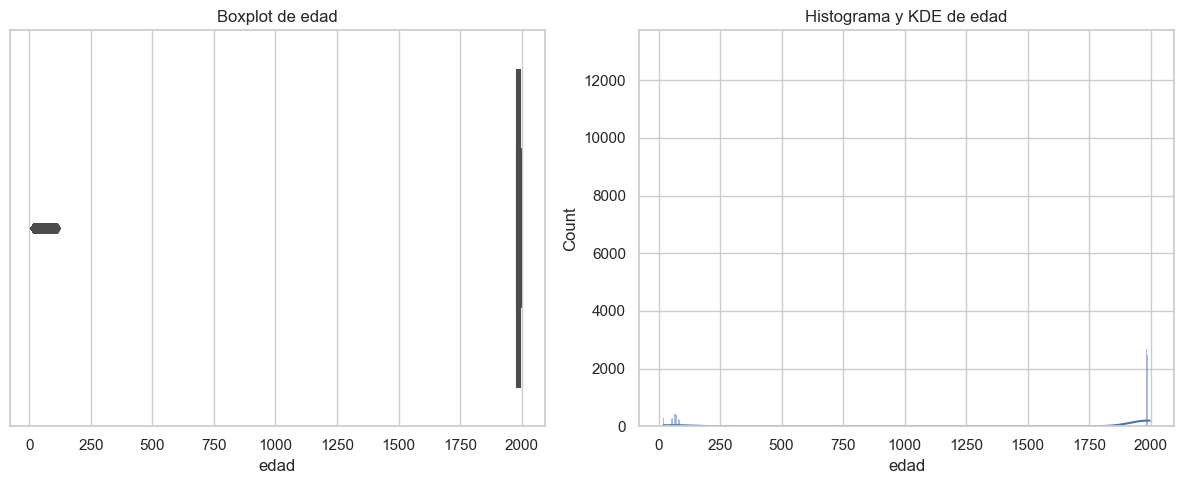

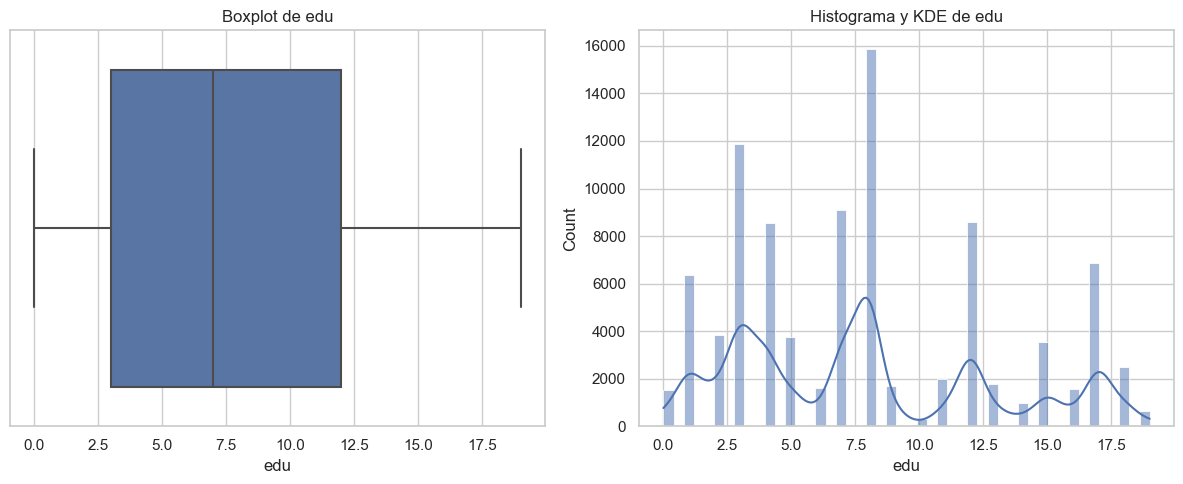

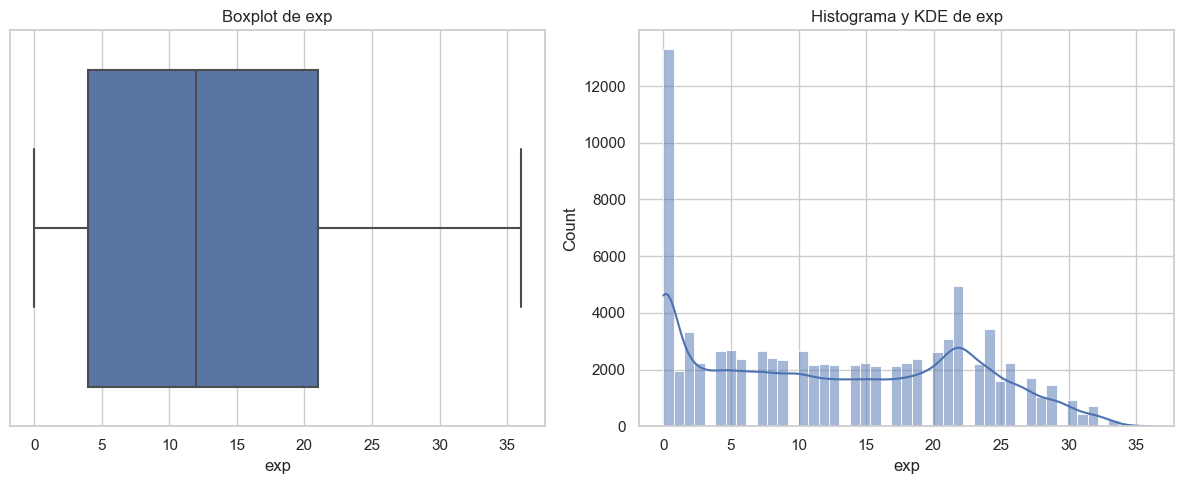

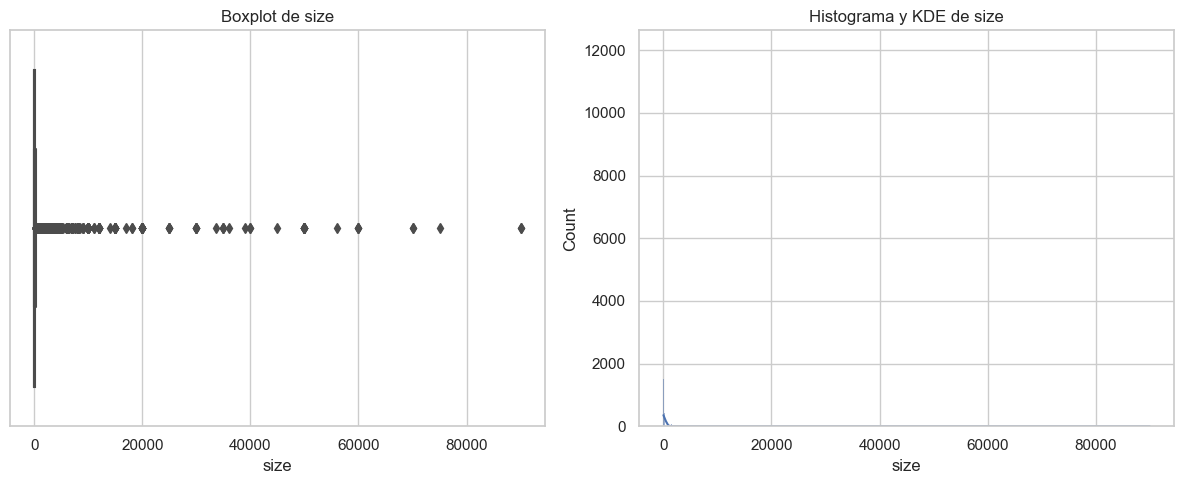

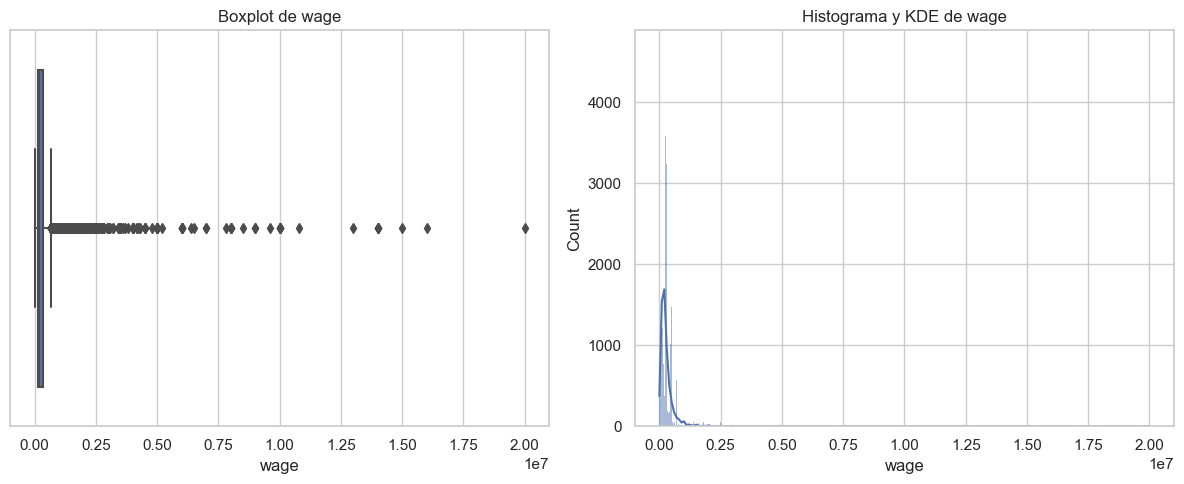

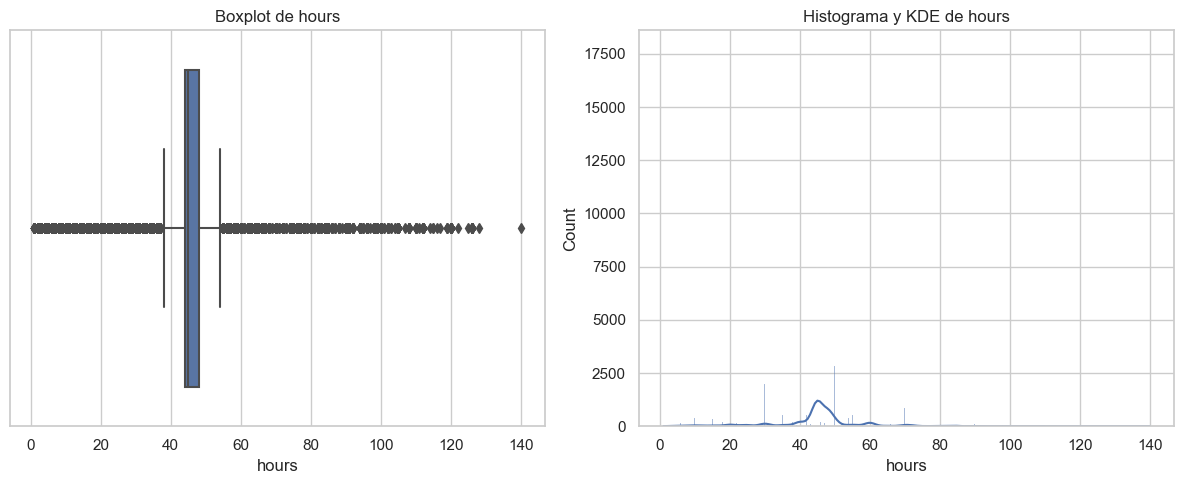

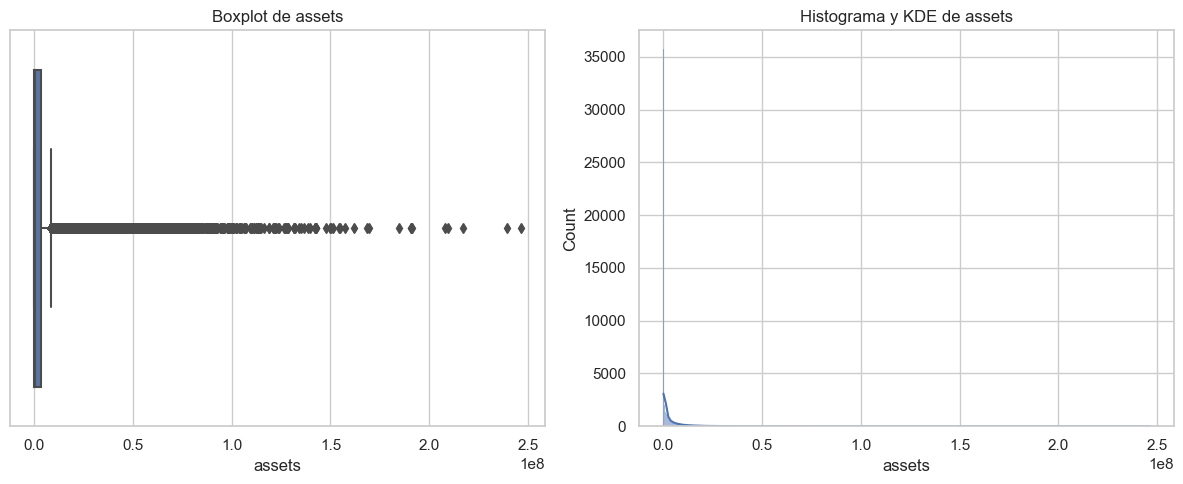

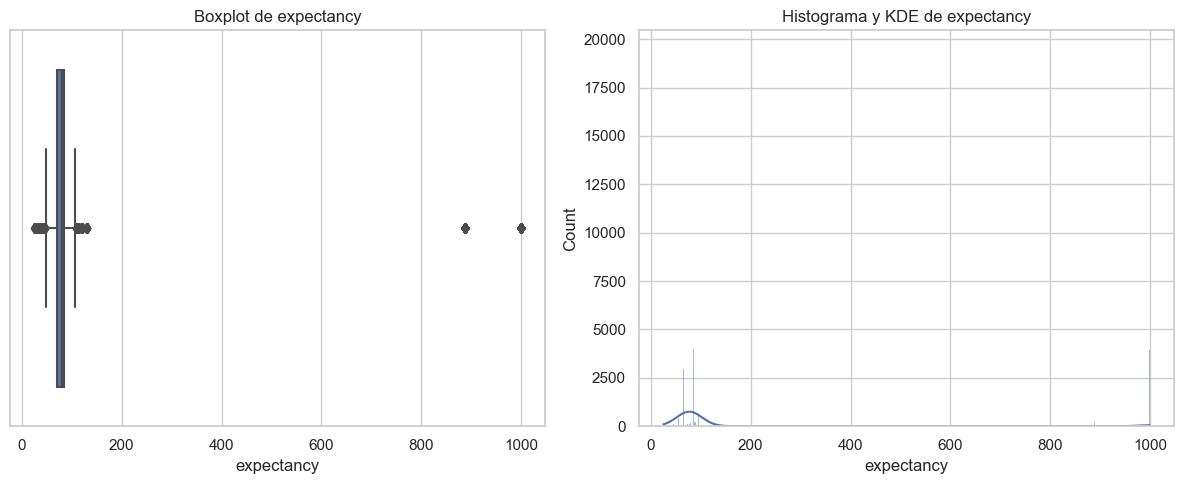

In [719]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variables continuas identificadas previamente
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
exclude_cols = ['folio_n20', 'time', 'hombre', 'region', 'status', 'kids', 'children', 'exp_sist']  # ajustar según datos
cont_cols = [col for col in num_cols if col not in exclude_cols and df[col].nunique() > 10]

for col in cont_cols:
    plt.figure(figsize=(12,5))

    # Boxplot
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')

    # Histograma + KDE
    plt.subplot(1, 2, 2)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histograma y KDE de {col}')

    plt.tight_layout()
    plt.show()


 Columnas con valores NaN (ordenadas de mayor a menor):
fondob        96846
fondoc        96846
fondoa        96846
fondod        96846
fondoe        96846
size          67802
informal      55587
occupation    47069
wage          42949
hours         42270
selfemp       41344
publicemp     41344
expectancy    26565
sistema       20643
children      18829
illness       16438
cronica       16309
nocronica     16309
mental        16309
assets        16087
region        15998
exp           11977
cotizando      4808
edu            3926
status          110
hombre           50
dtype: int64

 Columnas SIN valores NaN:
['folio_n20', 'year', 'time', 'edad', 'kids', 'situation', 'lmp', 'exp_sist']


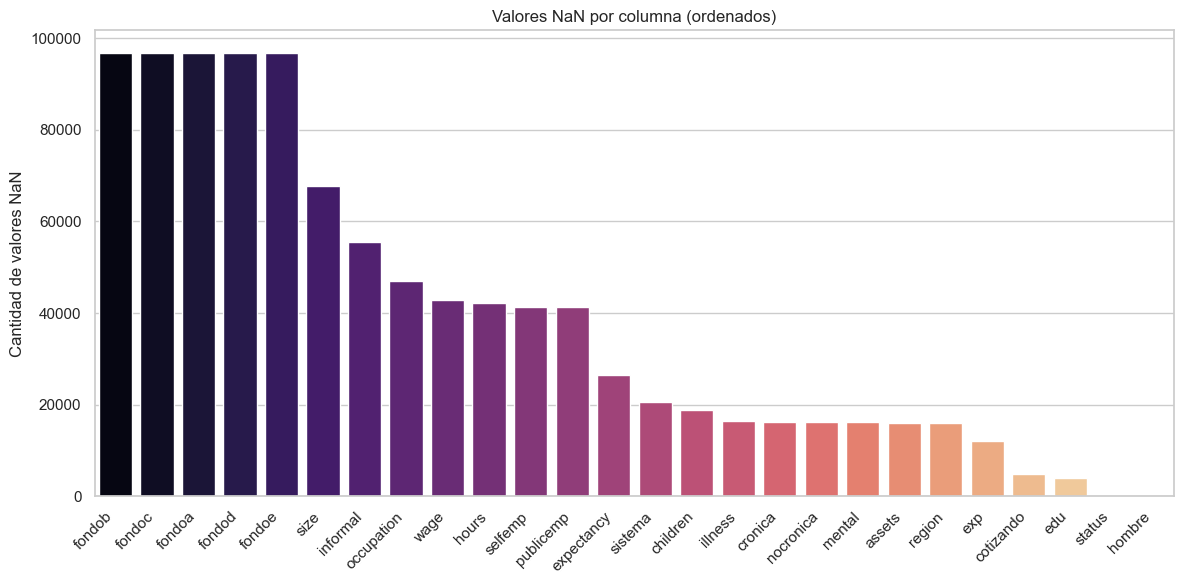

In [720]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar NaNs por columna
nan_counts = df.isna().sum()

# Filtrar columnas con y sin NaN
nan_counts_with_nan = nan_counts[nan_counts > 0].sort_values(ascending=False)
nan_counts_without_nan = nan_counts[nan_counts == 0]

# Mostrar en consola
print(" Columnas con valores NaN (ordenadas de mayor a menor):")
print(nan_counts_with_nan)
print("\n Columnas SIN valores NaN:")
print(nan_counts_without_nan.index.tolist())

# Gráfica de columnas con NaN
plt.figure(figsize=(12,6))
sns.barplot(x=nan_counts_with_nan.index, y=nan_counts_with_nan.values, palette='magma')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Cantidad de valores NaN')
plt.title('Valores NaN por columna (ordenados)')
plt.tight_layout()
plt.show()


In [721]:
import pandas as pd

# Supongamos que ya tienes tu DataFrame original llamado df

# Crear copia para análisis
df_prueba_variables = df.copy()

# Función para clasificar columnas
def classify_columns(df_prueba_variables):
    int_cols = []
    binary_cols = []
    categorical_cols = []

    for col in df_prueba_variables.columns:
        unique_vals = df_prueba_variables[col].dropna().unique()
        n_unique = len(unique_vals)
        dtype = df_prueba_variables[col].dtype

        if n_unique == 2:
            binary_cols.append(col)
        elif pd.api.types.is_integer_dtype(dtype) and n_unique > 2:
            int_cols.append(col)
        elif n_unique <= 10:
            categorical_cols.append(col)

    return int_cols, binary_cols, categorical_cols

# Ejecutar la clasificación
int_cols, binary_cols, categorical_cols = classify_columns(df_prueba_variables)

# Mostrar resultados
print("Columnas Enteras (int) con más de 2 valores únicos:")
print(int_cols)

print("\nColumnas Binarias (2 valores únicos excluyendo NaN):")
print(binary_cols)

print("\nColumnas Categóricas (<= 10 valores únicos):")
print(categorical_cols)



Columnas Enteras (int) con más de 2 valores únicos:
['folio_n20', 'year', 'time', 'edad', 'situation', 'lmp', 'exp_sist']

Columnas Binarias (2 valores únicos excluyendo NaN):
['hombre', 'kids', 'informal', 'selfemp', 'publicemp', 'sistema', 'cotizando', 'illness', 'cronica', 'nocronica', 'mental']

Columnas Categóricas (<= 10 valores únicos):
['status', 'children', 'occupation', 'fondoa', 'fondob', 'fondoc', 'fondod', 'fondoe']


In [722]:

df_copia = df.copy()

# Seleccionar las columnas de interés
columnas = ['time', 'edad', 'year']

# Agrupar por 'time' y tomar los primeros 20 registros por grupo
df_agrupado = (
    df_copia[columnas]
    .groupby('time', group_keys=False)
    .head(5)
    .sort_values(by=['time', 'year'], ascending=[True, True])
    .reset_index(drop=True)
)

# Mostrar el resultado
df_agrupado


,time,edad,year
0,1,1982,2
1,1,1982,2
2,1,1982,2
3,1,1982,2
4,1,48,2
5,2,49,4
6,2,1984,4
7,2,1984,4
8,2,1984,4
9,2,50,4


se eliminaron las variables relacionadas a los fondos dado que todas tenian valor nulo

In [723]:

df = df.drop(['fondob', 'fondoc', 'fondoa', 'fondod' ,'fondod','fondoe','size'], axis=1)

 Columnas con valores NaN (ordenadas de mayor a menor):
informal      55587
occupation    47069
wage          42949
hours         42270
selfemp       41344
publicemp     41344
expectancy    26565
sistema       20643
children      18829
illness       16438
nocronica     16309
cronica       16309
mental        16309
assets        16087
region        15998
exp           11977
cotizando      4808
edu            3926
status          110
hombre           50
dtype: int64

 Columnas SIN valores NaN:
['folio_n20', 'year', 'time', 'edad', 'kids', 'situation', 'lmp', 'exp_sist']


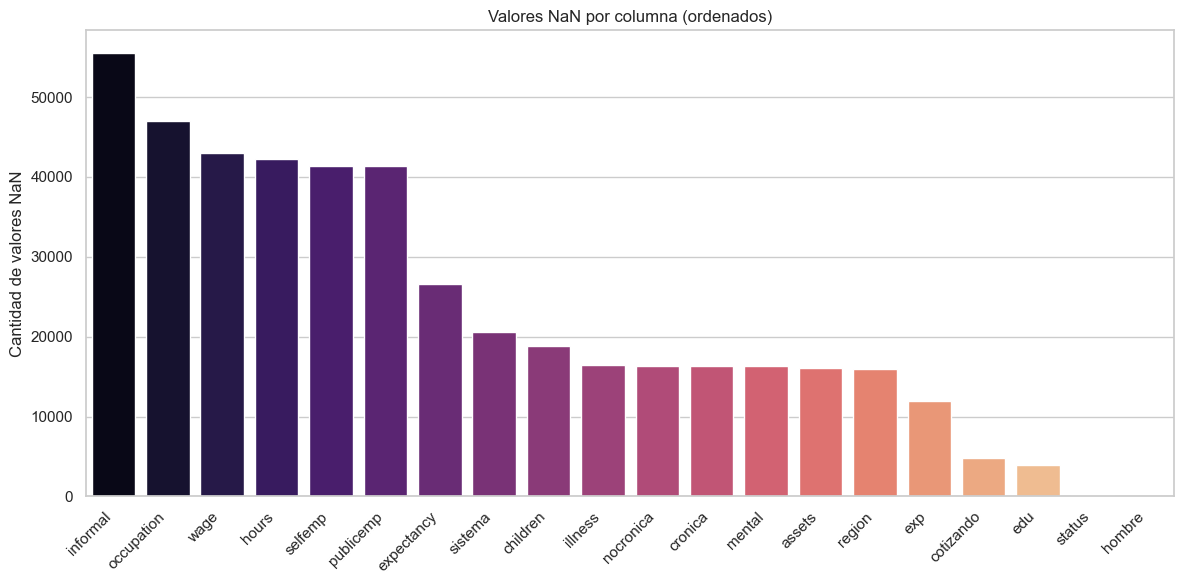

In [724]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar NaNs por columna
nan_counts = df.isna().sum()

# Filtrar columnas con y sin NaN
nan_counts_with_nan = nan_counts[nan_counts > 0].sort_values(ascending=False)
nan_counts_without_nan = nan_counts[nan_counts == 0]

# Mostrar en consola
print(" Columnas con valores NaN (ordenadas de mayor a menor):")
print(nan_counts_with_nan)
print("\n Columnas SIN valores NaN:")
print(nan_counts_without_nan.index.tolist())

# Gráfica de columnas con NaN
plt.figure(figsize=(12,6))
sns.barplot(x=nan_counts_with_nan.index, y=nan_counts_with_nan.values, palette='magma')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Cantidad de valores NaN')
plt.title('Valores NaN por columna (ordenados)')
plt.tight_layout()
plt.show()


# 1.2 eliminacion de los periodos 1 y 6
como se menciono anteriormente aqui se eliminaron del df los periodos 1 y 6 por los motivos mencionados

In [725]:
df = df[df['time'] != 1]
df = df[df['time'] != 6]

### 1.3 Creación de una variable binaria para representación laboral

La variable `suitation` indica la situación laboral de una persona, con cuatro categorías posibles (cesante, activo, etc.). Sin embargo, este nivel de detalle resulta innecesario para nuestro análisis, ya que solo nos interesa saber si la persona está trabajando o no.

Por esta razón, se creó una nueva variable llamada `trabaja_binaria`, que simplifica la información contenida en `suitation` y nos entrega directamente lo que necesitamos: si la persona trabaja o no.

La variable `trabaja_binaria` toma el valor:

- `1` si `suitation == 3` (lo que indica que la persona está trabajando),
- `0` para cualquier otro valor de `suitation`.

Esta transformación permite facilitar el análisis sin perder información relevante para los objetivos del estudio.


In [726]:
df["trabaja_binaria"] = (df["situation"] == 3).astype(int)

# 1.4 Variable indicadora para variables relacionadas al ámbito laboral

En los primeros intentos de realizar la tarea, se presentó un problema recurrente de multicolinealidad al agregar variables indicadoras para valores nulos en variables como años de experiencia o salario (`wage`). Tras reflexionar al respecto, comprendí que en realidad ya existía una variable indicadora implícita que capturaba esos casos: si la persona trabaja o no.
Un ejemplo simple: si una persona no trabaja, es natural que no tenga salario registrado o que este aparezca como nulo. En este contexto, el valor nulo no representa una ausencia de datos, sino más bien un valor estructural de cero, dado que la persona no trabaja. Sin embargo, también pueden darse casos en que una persona sí trabaja, pero aun así el salario aparece como nulo. En ese caso, sí estamos frente a una falta de información que debe ser señalada explícitamente.
Para abordar esta situación, se creó una variable llamada `info_lab_fal`, la cual busca identificar los casos en los que efectivamente hay una omisión informativa. Esta variable toma el valor 1 cuando la persona declara estar trabajando pero tiene experiencia laboral nula (no confundir con cero años) o cuando trabaja pero


In [727]:
# Crea la columna 'falta_info' que es 1 si trabaja pero exp y wage son 0 o NaN
df['info_lab_fal'] = df.apply(
    lambda row: 1 if (
        row['trabaja_binaria'] == 1 and 
        ( (pd.isna(row['exp']) ) or 
          (pd.isna(row['wage']) or row['wage'] == 0) )
    ) else 0,
    axis=1
)


In [728]:
df

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,cotizando,assets,exp_sist,expectancy,illness,cronica,nocronica,mental,trabaja_binaria,info_lab_fal
0,124560204870,4,2,49,0.0,7.0,5.0,3.0,1,1.0,...,0.0,0.0,0,58.0,1.0,0.0,1.0,0.0,0,0
1,124560204870,6,3,51,0.0,4.0,5.0,3.0,1,1.0,...,0.0,0.0,0,55.0,0.0,0.0,0.0,0.0,0,0
2,124560204870,9,4,54,0.0,5.0,5.0,3.0,1,1.0,...,0.0,0.0,0,70.0,1.0,0.0,0.0,1.0,0,0
3,124560204870,12,5,57,0.0,4.0,NaN,5.0,0,0.0,...,0.0,NaN,0,70.0,1.0,0.0,0.0,0.0,1,1
5,124560205935,4,2,1984,0.0,15.0,13.0,3.0,1,3.0,...,0.0,0.0,21,70.0,1.0,1.0,1.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96841,128133653188,12,5,1992,0.0,16.0,NaN,3.0,0,0.0,...,0.0,NaN,7,80.0,0.0,0.0,0.0,0.0,0,0
96842,128133692735,12,5,1992,0.0,12.0,NaN,2.0,0,0.0,...,1.0,NaN,7,80.0,1.0,0.0,0.0,0.0,1,1
96843,128133702320,12,5,1992,0.0,15.0,NaN,5.0,0,0.0,...,1.0,NaN,7,75.0,0.0,0.0,0.0,0.0,0,0
96844,128133728022,12,5,1992,0.0,8.0,NaN,2.0,0,0.0,...,1.0,NaN,6,70.0,1.0,0.0,0.0,0.0,1,1


# 1.5 Creacion de variables dummie,tratamiento de outliners y manupalcion de data para los modelos 

In [729]:
import pandas as pd
import numpy as np

df_modelos = df.copy()
#tratamiento de outliers en expectancy
def tratar_outliers(df, col):
    if col == 'expectancy':
        return df[df[col] <= 130]

for col in ['expectancy']:
    df_modelos = tratar_outliers(df_modelos, col)



#Crear variables dummy primero para evitar multicolinealidad con los indicadores de nulos
dummies_cols = ['occupation', 'situation','lmp']
df_modelos = pd.get_dummies(df_modelos, columns=dummies_cols, drop_first=True)

# 4. Procesar columnas numéricas y crear indicadores de nulos
cols_indicador = ['assets', 'edu', 'wage', 'hours', 'exp','sistema','illness']

for col in cols_indicador:
    # Crear variable indicadora de nulos
    df_modelos[f'{col}_isnull'] = df_modelos[col].isnull().astype(int)
    # Reemplazar los NaN en la columna original por 0
    df_modelos[col] = df_modelos[col].fillna(0)

# Transformar wage con logaritmo natural
df_modelos['log_wage'] = np.log(df_modelos['wage'] + 1)
df_modelos['log_assets'] = np.log(df_modelos['assets'] + 1)

# 1.6 verificacion del df utilizado para correr los modelos
se hicieron graficos y diferentes cosas para antes de arrancar los modelos,estuviera seguro de que el trabajo realizado en la preparacion de data estuviera todo correcto

# 1.6.1 grafico de caja y dispercion

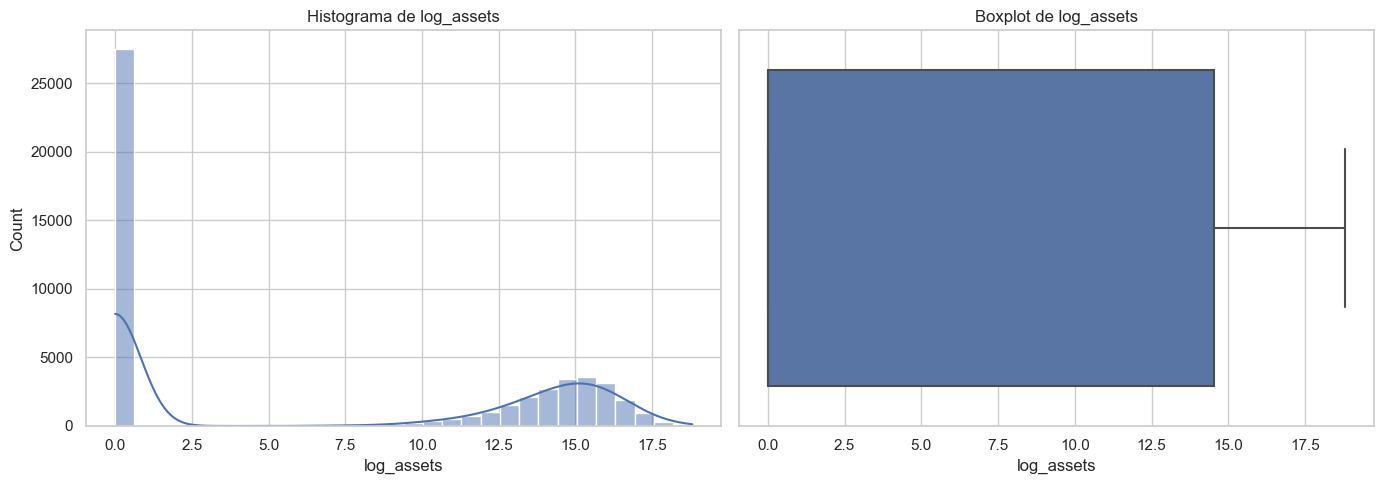

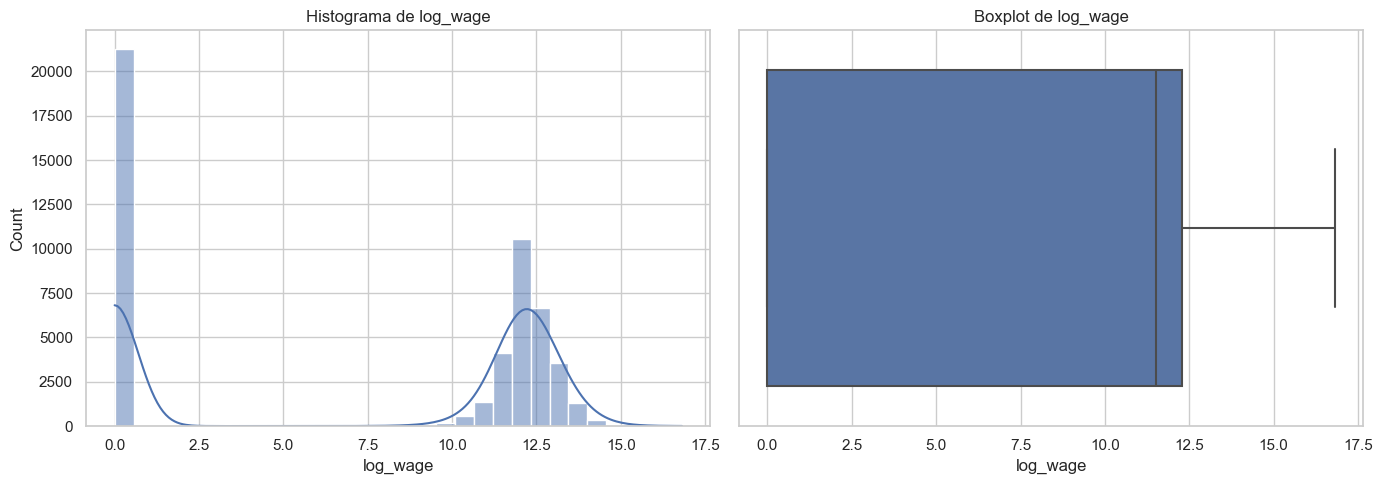

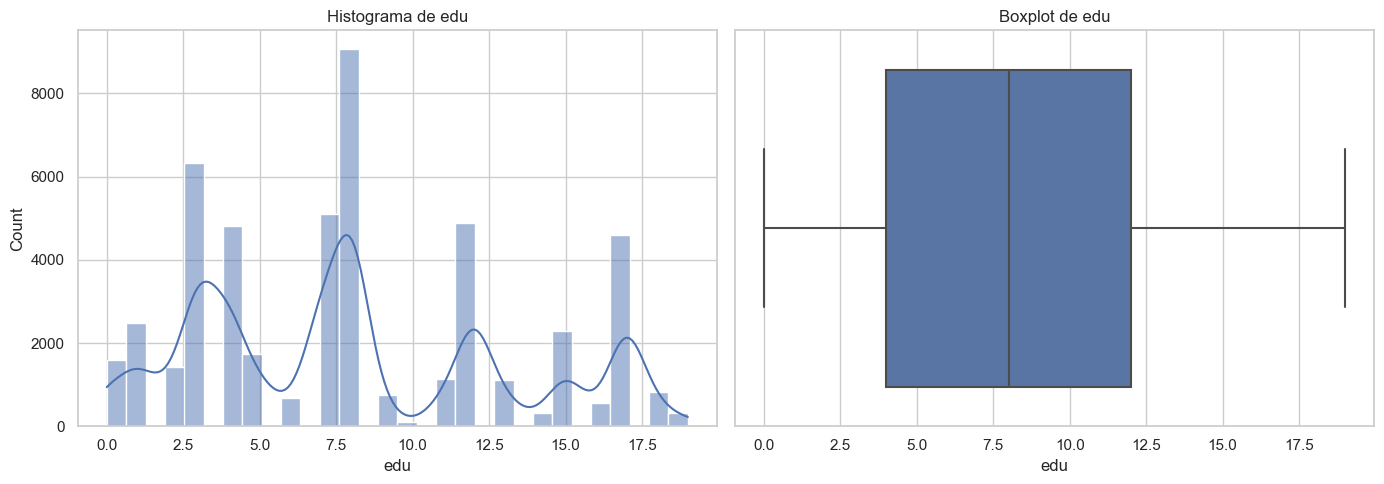

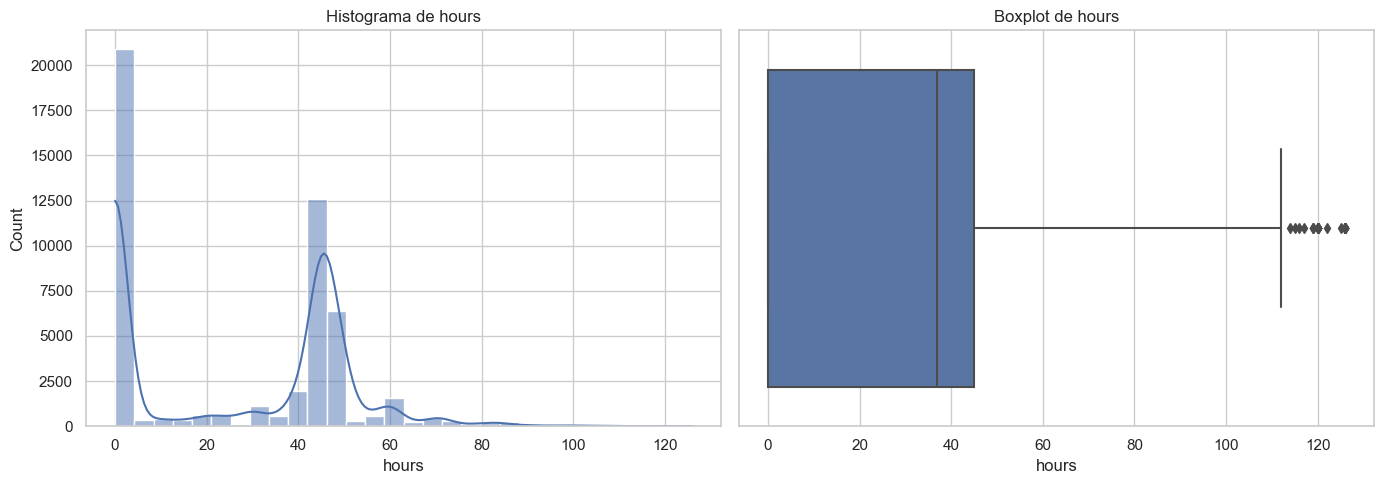

In [730]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de variables a graficar
variables = ['log_assets', 'log_wage', 'edu','hours']

# Estilo
sns.set(style="whitegrid")

# Recorrer cada variable
for var in variables:
    plt.figure(figsize=(14, 5))

    # Histograma con curva KDE
    plt.subplot(1, 2, 1)
    sns.histplot(df_modelos[var], kde=True, bins=30)
    plt.title(f'Histograma de {var}')
    plt.xlabel(var)

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_modelos[var])
    plt.title(f'Boxplot de {var}')
    plt.xlabel(var)

    plt.tight_layout()
    plt.show()



In [731]:
df_modelos

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,lmp_2,assets_isnull,edu_isnull,wage_isnull,hours_isnull,exp_isnull,sistema_isnull,illness_isnull,log_wage,log_assets
0,124560204870,4,2,49,0.0,7.0,5.0,3.0,1,1.0,...,0,0,0,1,1,1,1,0,0.000000,0.0
1,124560204870,6,3,51,0.0,4.0,5.0,3.0,1,1.0,...,0,0,0,1,1,1,0,0,0.000000,0.0
2,124560204870,9,4,54,0.0,5.0,5.0,3.0,1,1.0,...,0,0,0,1,1,1,0,0,0.000000,0.0
3,124560204870,12,5,57,0.0,4.0,NaN,5.0,0,0.0,...,0,1,0,0,0,1,0,0,10.819798,0.0
5,124560205935,4,2,1984,0.0,15.0,13.0,3.0,1,3.0,...,0,0,0,1,1,0,0,0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96841,128133653188,12,5,1992,0.0,16.0,NaN,3.0,0,0.0,...,0,1,0,1,1,1,0,0,0.000000,0.0
96842,128133692735,12,5,1992,0.0,12.0,NaN,2.0,0,0.0,...,1,1,0,0,0,1,0,0,11.918397,0.0
96843,128133702320,12,5,1992,0.0,15.0,NaN,5.0,0,0.0,...,0,1,0,1,1,1,0,0,0.000000,0.0
96844,128133728022,12,5,1992,0.0,8.0,NaN,2.0,0,0.0,...,1,1,0,0,0,1,0,0,12.117247,0.0


# 1.6.2 verificacion de valores nulos 

In [732]:
# VALORES NULOS POR COLUMNA
print(" VALORES NULOS POR COLUMNA")

nulls = df_modelos.isnull().sum().sort_values(ascending=False)
nulls_percent = (nulls / len(df_modelos) * 100).round(2)
null_summary = pd.DataFrame({'Nulos': nulls, '% Nulos': nulls_percent})

display(null_summary[null_summary['Nulos'] > 0])
print("\n")

 VALORES NULOS POR COLUMNA


,Nulos,% Nulos
informal,27709,55.31
selfemp,20237,40.40
publicemp,20237,40.40
region,12610,25.17
children,6494,12.96
cotizando,2991,5.97
status,48,0.10
hombre,23,0.05


# 1.7 Realizacion de set_index

In [733]:
df_modelos=df_modelos.set_index(["folio_n20","time"])
df_modelos

year  edad  hombre   edu  region  status  kids  children  \
folio_n20    time                                                             
124560204870 2        4    49     0.0   7.0     5.0     3.0     1       1.0   
             3        6    51     0.0   4.0     5.0     3.0     1       1.0   
             4        9    54     0.0   5.0     5.0     3.0     1       1.0   
             5       12    57     0.0   4.0     NaN     5.0     0       0.0   
124560205935 2        4  1984     0.0  15.0    13.0     3.0     1       3.0   
...                 ...   ...     ...   ...     ...     ...   ...       ...   
128133653188 5       12  1992     0.0  16.0     NaN     3.0     0       0.0   
128133692735 5       12  1992     0.0  12.0     NaN     2.0     0       0.0   
128133702320 5       12  1992     0.0  15.0     NaN     5.0     0       0.0   
128133728022 5       12  1992     0.0   8.0     NaN     2.0     0       0.0   
128133731927 5       12  1992     1.0   8.0     NaN     2.0     0       0.0   

                   exp      wage  ...  lmp_2  assets_isnull  edu_isnull  \
folio_n20    time                 ...                                     
124560204870 2     0.0       0.0  ...      0              0           0   
             3     0.0       0.0  ...      0              0           0   
             4     0.0       0.0  ...      0              0           0   
             5     0.0   50000.0  ...      0              1           0   
124560205935 2     6.0       0.0  ...      0              0           0   
...                ...       ...  ...    ...            ...         ...   
128133653188 5     0.0       0.0  ...      0              1           0   
128133692735 5     0.0  150000.0  ...      1              1           0   
128133702320 5     0.0       0.0  ...      0              1           0   
128133728022 5     0.0  183000.0  ...      1              1           0   
128133731927 5     0.0  270000.0  ...      1              1           0   

                   wage_isnull  hours_isnull  exp_isnull  sistema_isnull  \
folio_n20    time                                                          
124560204870 2               1             1           1               1   
             3               1             1           1               0   
             4               1             1           1               0   
             5               0             0           1               0   
124560205935 2               1             1           0               0   
...                        ...           ...         ...             ...   
128133653188 5               1             1           1               0   
128133692735 5               0             0           1               0   
128133702320 5               1             1           1               0   
128133728022 5               0             0           1               0   
128133731927 5               0             0           1               0   

                   illness_isnull   log_wage  log_assets  
folio_n20    time                                         
124560204870 2                  0   0.000000         0.0  
             3                  0   0.000000         0.0  
             4                  0   0.000000         0.0  
             5                  0  10.819798         0.0  
124560205935 2                  0   0.000000         0.0  
...                           ...        ...         ...  
128133653188 5                  0   0.000000         0.0  
128133692735 5                  0  11.918397         0.0  
128133702320 5                  0   0.000000         0.0  
128133728022 5                  0  12.117247         0.0  
128133731927 5                  0  12.506181         0.0  

[50096 rows x 48 columns]

# 2) modelos 2,3,4

# 2.1 Modelo Pooled

In [734]:
#Minimo cuadrado agrupado
y=df_modelos['expectancy']
X=df_modelos[['edu','log_wage','exp','hours','log_assets','sistema','assets_isnull','sistema_isnull','edu_isnull','trabaja_binaria','occupation_2.0','occupation_3.0','occupation_4.0','occupation_5.0','occupation_6.0','occupation_7.0','occupation_8.0','occupation_9.0','occupation_10.0',
'cronica','nocronica','mental','illness','illness_isnull','info_lab_fal']]
X=sm.add_constant(X)
model = lmp.PanelOLS(y, X)
mco = model.fit()
print(mco)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0323
Estimator:                   PanelOLS   R-squared (Between):              0.0405
No. Observations:               50096   R-squared (Within):               0.0060
Date:              mar., may. 20 2025   R-squared (Overall):              0.0323
Time:                        21:59:34   Log-likelihood                -1.877e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      66.809
Entities:                       23930   P-value                           0.0000
Avg Obs:                       2.0934   Distribution:                F(25,50070)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             66.809
                            

# 2.2 Modelo Efectos fijos

In [735]:

y=df_modelos['expectancy']
X_2=df_modelos[['edu','log_wage','exp','hours','log_assets','sistema','assets_isnull','edu_isnull','trabaja_binaria','occupation_2.0','occupation_3.0','occupation_4.0','occupation_5.0','occupation_6.0','occupation_7.0','occupation_8.0','occupation_9.0','occupation_10.0',
'cronica','nocronica','mental','illness','illness_isnull','info_lab_fal']]
X_2=sm.add_constant(X_2)

model=lmp.PanelOLS(y,X_2, entity_effects=True)
fe=model.fit(cov_type="robust")
print(fe)



                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0271
Estimator:                   PanelOLS   R-squared (Between):             -0.1008
No. Observations:               50096   R-squared (Within):               0.0271
Date:              mar., may. 20 2025   R-squared (Overall):             -0.0562
Time:                        21:59:35   Log-likelihood                -1.615e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      30.302
Entities:                       23930   P-value                           0.0000
Avg Obs:                       2.0934   Distribution:                F(24,26142)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             20.492
                            

# 2.3 Modelo efectos aleatorios

In [736]:
model=lmp.RandomEffects(y,X_2)
re=model.fit(cov_type="robust")
print(re)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.4101
Estimator:              RandomEffects   R-squared (Between):              0.0237
No. Observations:               50096   R-squared (Within):               0.0165
Date:              mar., may. 20 2025   R-squared (Overall):              0.0229
Time:                        21:59:35   Log-likelihood                 -1.78e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      1450.2
Entities:                       23930   P-value                           0.0000
Avg Obs:                       2.0934   Distribution:                F(24,50071)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             41.078
                            

# 3 Comparacion de modelos

# 3.1 comparacion de modelos

In [737]:
print(lmp.compare({"FE": fe, "RE": re, "Pooled": mco}))

                            Model Comparison                           
                                    FE                RE         Pooled
-----------------------------------------------------------------------
Dep. Variable               expectancy        expectancy     expectancy
Estimator                     PanelOLS     RandomEffects       PanelOLS
No. Observations                 50096             50096          50096
Cov. Est.                       Robust            Robust     Unadjusted
R-squared                       0.0271            0.4101         0.0323
R-Squared (Within)              0.0271            0.0165         0.0060
R-Squared (Between)            -0.1008            0.0237         0.0405
R-Squared (Overall)            -0.0562            0.0229         0.0323
F-statistic                     30.302            1450.2         66.809
P-value (F-stat)                0.0000            0.0000         0.0000
=====================     ============   ===============   =====

In [738]:
re.variance_decomposition

Effects                   34.833602
Residual                  70.862500
Percent due to Effects     0.329564
Name: Variance Decomposition, dtype: float64

# 3.2 Test de Hausman

In [739]:
import numpy.linalg as la
from scipy import stats

def hausman(fe, re):
 diff = fe.params-re.params
 psi = fe.cov - re.cov
 dof = diff.size -1
 W = diff.dot(la.inv(psi)).dot(diff)
 pval = stats.chi2.sf(W, dof)
 return W, dof, pval

htest = hausman(fe, re) 
print("Hausman Test: chi-2 = {0}, df = {1}, p-value = {2}".format(htest[0], htest[1], htest[2]))

Hausman Test: chi-2 = 302.09410910224307, df = 24, p-value = 6.350022888743592e-50


# 4 Modelo Cre y analisis de heterogenidad

# 4.1 Modelo CRE

In [740]:
X_cre =['edu','log_wage','exp','hours','log_assets','sistema','assets_isnull','edu_isnull','hours_isnull','trabaja_binaria','occupation_2.0','occupation_3.0','occupation_4.0','occupation_5.0','occupation_6.0','occupation_7.0','occupation_8.0','occupation_9.0','occupation_10.0',
'cronica','nocronica','mental','illness','illness_isnull','info_lab_fal']
# Calculamos la media de cada variable "time-varying" por persona (folio_n20)
Xm = df_modelos.groupby(level=0)[X_cre].transform('mean')
Xm.columns = ['mean_' + col for col in Xm.columns]

# Unimos la tabla de medias a la original
df_cre_m = pd.concat([df_modelos, Xm], axis=1)

# Variable dependiente
y = df_cre_m['expectancy'].astype(float)

# Variables independientes: originales y sus medias ("mean_var")
X_cre_v = df_cre_m[
    X_cre + ['mean_' + v for v in X_cre]
].astype(float)

# Añadimos la constante:
X_cre_v = sm.add_constant(X_cre_v)

from linearmodels.panel import RandomEffects

cre_model = RandomEffects(y, X_cre_v)
cre = cre_model.fit(cov_type='robust')
print(cre)


                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.4164
Estimator:              RandomEffects   R-squared (Between):              0.0338
No. Observations:               50096   R-squared (Within):               0.0271
Date:              mar., may. 20 2025   R-squared (Overall):              0.0334
Time:                        21:59:37   Log-likelihood                -1.777e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      714.13
Entities:                       23930   P-value                           0.0000
Avg Obs:                       2.0934   Distribution:                F(50,50045)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             30.638
                            

# 4.3 Grafico para ver heterogeneidad

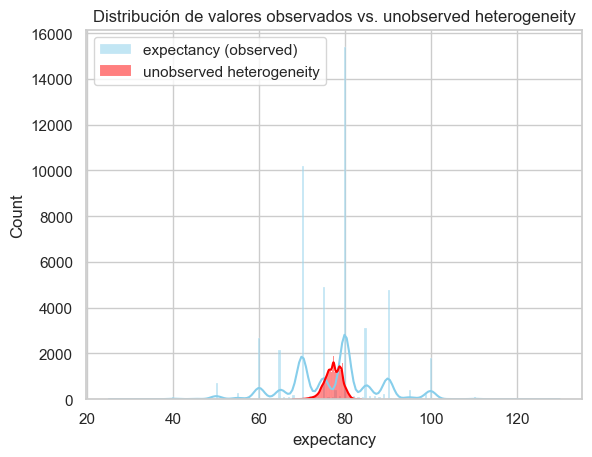

In [741]:
import seaborn as sns
import matplotlib.pyplot as plt

# Obtener predicciones del modelo (ajustadas)
yhat = cre.predict().fitted_values  # Predicciones ajustadas del modelo

# Graficar histogramas con KDE
sns.histplot(data=y, color="skyblue", label="expectancy (observed)", kde=True)
sns.histplot(data=yhat, color="red", label="unobserved heterogeneity", kde=True)

plt.legend()
plt.xlabel("expectancy")
plt.title("Distribución de valores observados vs. unobserved heterogeneity")
plt.show()


# 4.3 Comparacion de RE V/S FE V/S CRE

In [742]:
print(lmp.compare({"FE": fe, "RE": re, "CRE": cre}))

                              Model Comparison                             
                                     FE                RE               CRE
---------------------------------------------------------------------------
Dep. Variable                expectancy        expectancy        expectancy
Estimator                      PanelOLS     RandomEffects     RandomEffects
No. Observations                  50096             50096             50096
Cov. Est.                        Robust            Robust            Robust
R-squared                        0.0271            0.4101            0.4164
R-Squared (Within)               0.0271            0.0165            0.0271
R-Squared (Between)             -0.1008            0.0237            0.0338
R-Squared (Overall)             -0.0562            0.0229            0.0334
F-statistic                      30.302            1450.2            714.13
P-value (F-stat)                 0.0000            0.0000            0.0000
============

# 4.4 Estadistica complementaria

In [743]:
# Extraer sigma_u (componente individual) y sigma_e (error idiosincrático)
sigma_u = cre.variance_decomposition['Effects']
sigma_e = cre.variance_decomposition['Residual']

# Calcula rho (fracción explicada por heterogeneidad no observada)
rho = sigma_u / (sigma_u + sigma_e)

print(f"Fracción de varianza explicada por u_i (rho): {rho:.4f} ({rho*100:.2f}%)")

Fracción de varianza explicada por u_i (rho): 0.3295 (32.95%)
